# Q3. Parts of Speech (POS) taggers & Syntactic Analysers 

---

Cell 1: Setup and Reading the Data

In [6]:
# Read Data_2.txt
with open('../assets/dataset-a/Data_2.txt', 'r') as file:
    text03 = file.read().strip()
    
print("Original Text:\n", text03)

Original Text:
 The big black dog barked at the white cat and chased away.


### Cell 2: Tokenization

Hugging Face's BasicTokenizer. It does whole-word tokenization, safely separates punctuation into their own tokens, and keeps uppercase letters intact—which is exactly what NLTK and Regex POS taggers need to work perfectly.

In [ ]:
!pip install transformers

In [7]:
# 2. Tokenize using Hugging Face BasicTokenizer 
from transformers import BasicTokenizer

# We set do_lower_case=False because capital letters help POS taggers identify Proper Nouns
tokenizer = BasicTokenizer(do_lower_case=False)
hf_tokens = tokenizer.tokenize(text03)

print("Tokens for POS Tagging (Hugging Face):\n", hf_tokens)
print("-" * 50)

Tokens for POS Tagging (Hugging Face):
 ['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away', '.']
--------------------------------------------------


### 3.1. Demo - POS Tagging (NLTK, TextBlob, RegEx)

In [8]:
import nltk
from textblob import TextBlob

# Ensure required NLTK tagger resources are downloaded
nltk.download('averaged_perceptron_tagger')

print("--- 1. NLTK POS Tagger ---")
# Feed the Hugging Face tokens directly to NLTK
nltk_pos_tags = nltk.pos_tag(hf_tokens)
print(nltk_pos_tags)
print("\n")


print("--- 2. TextBlob POS Tagger ---")
# Since TextBlob.words is banned for you, we just pass the raw text03 string. 
# TextBlob will handle it internally without you explicitly calling its tokenizer.
blob = TextBlob(text03)
textblob_pos_tags = blob.tags
print(textblob_pos_tags)
print("\n")


print("--- 3. Regular Expression POS Tagger ---")
# Define grammar rules based on word endings
patterns = [
    (r'.*ing$', 'VBG'),                # Gerunds
    (r'.*ed$', 'VBD'),                 # Simple past verbs
    (r'.*es$', 'VBZ'),                 # 3rd singular present verbs
    (r'.*ould$', 'MD'),                # Modals
    (r'.*\'s$', 'NN$'),                # Possessive nouns
    (r'.*s$', 'NNS'),                  # Plural nouns
    (r'^-?[0-9]+(\.[0-9]+)?$', 'CD'),  # Cardinal numbers
    (r'(?i)^(the|a|an)$', 'DT'),       # Determiners/Articles
    (r'.*able$', 'JJ'),                # Adjectives
    (r'.*', 'NN')                      # Default fallback rule: Tag everything else as a Noun
]

regex_tagger = nltk.RegexpTagger(patterns)
# Feed the Hugging Face tokens to the Regex Tagger
regex_pos_tags = regex_tagger.tag(hf_tokens)
print(regex_pos_tags)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\sheng\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


--- 1. NLTK POS Tagger ---
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB'), ('.', '.')]


--- 2. TextBlob POS Tagger ---
[('The', 'DT'), ('big', 'JJ'), ('black', 'JJ'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'IN'), ('the', 'DT'), ('white', 'JJ'), ('cat', 'NN'), ('and', 'CC'), ('chased', 'VBD'), ('away', 'RB')]


--- 3. Regular Expression POS Tagger ---
[('The', 'DT'), ('big', 'NN'), ('black', 'NN'), ('dog', 'NN'), ('barked', 'VBD'), ('at', 'NN'), ('the', 'DT'), ('white', 'NN'), ('cat', 'NN'), ('and', 'NN'), ('chased', 'VBD'), ('away', 'NN'), ('.', 'NN')]


### Comparative Analysis of POS Tagging Outputs

The table below presents a side-by-side comparison of the Part-of-Speech (POS) tags assigned to each token by the three different taggers: NLTK, TextBlob, and the custom Regular Expression tagger.

| Token | NLTK Tagger (Machine Learning) | TextBlob Tagger (Machine Learning) | Regular Expression Tagger (Rule-Based) |
| :--- | :--- | :--- | :--- |
| **The** | DT (Determiner) | DT (Determiner) | DT (Determiner) |
| **big** | JJ (Adjective) | JJ (Adjective) | **NN (Noun - Incorrect)** |
| **black** | JJ (Adjective) | JJ (Adjective) | **NN (Noun - Incorrect)** |
| **dog** | NN (Noun) | NN (Noun) | NN (Noun) |
| **barked** | VBD (Verb, past tense) | VBD (Verb, past tense) | VBD (Verb, past tense) |
| **at** | IN (Preposition) | IN (Preposition) | **NN (Noun - Incorrect)** |
| **the** | DT (Determiner) | DT (Determiner) | DT (Determiner) |
| **white** | JJ (Adjective) | JJ (Adjective) | **NN (Noun - Incorrect)** |
| **cat** | NN (Noun) | NN (Noun) | NN (Noun) |
| **and** | CC (Conjunction) | CC (Conjunction) | **NN (Noun - Incorrect)** |
| **chased** | VBD (Verb, past tense) | VBD (Verb, past tense) | VBD (Verb, past tense) |
| **away** | RB (Adverb) | RB (Adverb) | **NN (Noun - Incorrect)** |
| **.** | . (Punctuation) | *(Dropped automatically)* | **NN (Noun - Incorrect)** |




### 3.2 Differences between the POS taggers based on the output

Based on the outputs obtained, the three POS taggers exhibit distinct differences in their underlying mechanisms and accuracy:

- **Context-Awareness (NLTK vs. Regular Expression):** NLTK and TextBlob are based on pre-trained machine learning models that evaluate a word's surrounding grammatical context. Because of this, they correctly identified `big`, `black`, and `white` as Adjectives (`JJ`) because they precede nouns. In contrast, the Regular Expression tagger is completely blind to context and relies solely on morphological rules (word spelling/endings). Because `big`, `black`, and `away` do not possess specific suffixes (like *-ed* or *-ing*), the RegEx tagger failed to identify them, forcing them into its default fallback category as Nouns (`NN`).

- **Rule-Based Successes (Regular Expression):** Despite its failures on general vocabulary, the RegEx tagger performs identically to the ML-based taggers (NLTK & TextBlob) only when words explicitly match defined rules. For example, all three taggers correctly identified `barked` and `chased` as Past-Tense Verbs (`VBD`)—NLTK and TextBlob did so through contextual probability, whereas the RegEx tagger succeeded simply because the words ended in the explicit regex suffix `.*ed$`.

- **Punctuation Handling (NLTK vs. TextBlob):** While NLTK and TextBlob share similar high accuracy for tagging words, they differ in how they process raw text objects. NLTK treats punctuation as a valid token and successfully tagged the period at the end of the sentence as punctuation `('.', '.')`. TextBlob’s internal tokenizer automatically strips punctuation during its tagging process, meaning the period was entirely dropped from its output.

### 3.3 Generating Parse Trees using NLTK

In [9]:
import nltk

# 1. Define the Grammar Rules for your specific sentence
# S = Sentence, NP = Noun Phrase, VP = Verb Phrase, PP = Prepositional Phrase
grammar = nltk.CFG.fromstring("""
  S -> NP VP PUNCT
  NP -> DT JJ JJ NN | DT JJ NN 
  VP -> VBD PP CC VBD ADVP
  PP -> IN NP
  ADVP -> RB
  
  DT -> 'The' | 'the'
  JJ -> 'big' | 'black' | 'white'
  NN -> 'dog' | 'cat'
  VBD -> 'barked' | 'chased'
  IN -> 'at'
  CC -> 'and'
  RB -> 'away'
  PUNCT -> '.'
""")

# 2. Create the parser
parser = nltk.ChartParser(grammar)

# 3. Define the sentence tokens (Ensure it matches the grammar exactly)
sentence_tokens = ['The', 'big', 'black', 'dog', 'barked', 'at', 'the', 'white', 'cat', 'and', 'chased', 'away', '.']

print("--- Text Based Parse Tree ---")
# 4. Generate and print the trees
for tree in parser.parse(sentence_tokens):
    print(tree)
    
    # NOTE: The line below will open a new popup window showing the graphical tree!
    # Take a screenshot of that popup window to put in your Word Document report.
    tree.draw()

--- Text Based Parse Tree ---
(S
  (NP (DT The) (JJ big) (JJ black) (NN dog))
  (VP
    (VBD barked)
    (PP (IN at) (NP (DT the) (JJ white) (NN cat)))
    (CC and)
    (VBD chased)
    (ADVP (RB away)))
  (PUNCT .))


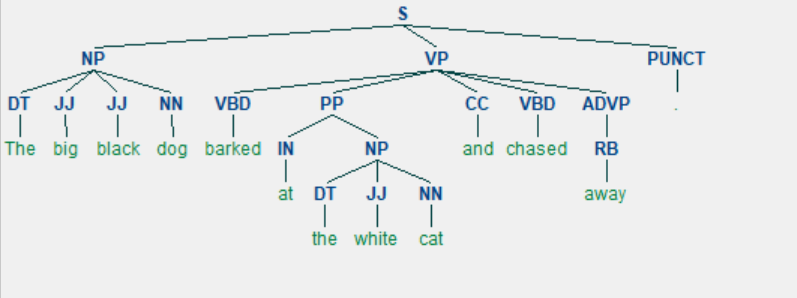